In [ ]:
# ===== Cell 1: Imports =====
import os
import time
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path
import xlsxwriter
from datetime import timedelta
import requests

# ===== End of Cell 1 =====

In [ ]:
# ===== Cell 2: Automated Online Data Acquisition (Tiingo) =====

# --- 1. Configuration ---
TIINGO_API_KEY = "XXXXXXX"
SAVE_DIR = Path("../data/raw_data")
os.makedirs(SAVE_DIR, exist_ok=True)

# Fetching from 2019 to ensure enough lookback for a 2020 training start
FETCH_START = "2019-09-01"
FETCH_END = "2025-12-31"

# Matching your Production List (48 Stocks)
stocks_to_fetch = [
    "AAPL", "ABBV", "ADBE", "AMD", "AMT", "AMZN", "AVGO", "BAC", "BHP", "BLK",
    "BP", "COP", "COST", "CVX", "DLR", "EQIX", "FCX", "GOOGL", "GS", "INTC",
    "JNJ", "JPM", "LIN", "LLY", "META", "MRK", "MS", "NEM", "NFLX", "NVDA",
    "O", "PEP", "PFE", "PLD", "QCOM", "RIO", "SCCO", "SCHW", "SHW", "SLB",
    "SPG", "TMO", "TSLA", "TTE", "UNH", "WELL", "WFC", "XOM"
]

def fetch_and_save_raw(ticker):
    file_path = SAVE_DIR / f"{ticker}_RAW.csv"

    # Skip if already exists to save API credits and time
    if file_path.exists():
        return True

    headers = {'Content-Type': 'application/json'}
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    params = {
        'startDate': FETCH_START,
        'endDate': FETCH_END,
        'token': TIINGO_API_KEY,
        'format': 'json'
    }

    try:
        response = requests.get(url, params=params, headers=headers)
        if response.status_code == 200:
            raw_data = response.json()
            if not raw_data: return False

            df = pd.DataFrame(raw_data)
            # Select Adjusted columns for splits/dividends
            clean_df = df[['date', 'adjOpen', 'adjHigh', 'adjLow', 'adjClose', 'adjVolume']].copy()
            clean_df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
            clean_df['Date'] = pd.to_datetime(clean_df['Date']).dt.date

            clean_df.to_csv(file_path, index=False)
            print(f" {ticker}: {len(clean_df)} days saved.")
            return True
        else:
            print(f" Error {response.status_code} for {ticker}")
            return False
    except Exception as e:
        print(f" Exception fetching {ticker}: {e}")
        return False

# --- 2. Execution ---
print(f" Verifying/Fetching raw data for {len(stocks_to_fetch)} stocks...")
for i, ticker in enumerate(stocks_to_fetch):
    success = fetch_and_save_raw(ticker)
    # Tiingo Rate Limit Protection
    if i < len(stocks_to_fetch) - 1 and success:
        time.sleep(3) # Small sleep for verification; Tiingo allows 50/hour or 2/sec depending on tier

print(f" Data Directory Synchronized.")

# ===== End of Cell 2 =====

In [ ]:
# ===== Cell 3: Final Production - Raw/Processed & Standardized M=55 Data =====

# --- 1. CONFIGURATION ---
M_TRADING_DAYS = 55
TARGET_DAYS = 5
ATR_MULTIPLIER = 1.5
EMBEDDING_DIM = 8
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"

STOCKS_LIST = [
    "AAPL", "ABBV", "ADBE", "AMD", "AMT", "AMZN", "AVGO", "BAC", "BHP", "BLK",
    "BP", "COP", "COST", "CVX", "DLR", "EQIX", "FCX", "GOOGL", "GS", "INTC",
    "JNJ", "JPM", "LIN", "LLY", "META", "MRK", "MS", "NEM", "NFLX", "NVDA",
    "O", "PEP", "PFE", "PLD", "QCOM", "RIO", "SCCO", "SCHW", "SHW", "SLB",
    "SPG", "TMO", "TSLA", "TTE", "UNH", "WELL", "WFC", "XOM"
]

BASE_DATA = Path("../data")
INPUT_DIR = BASE_DATA / "raw_data"
PROCESSED_EXCEL_DIR = BASE_DATA / "formatted_data" / "atr_1.5_processed"
RAW_EXCEL_DIR = BASE_DATA / "formatted_data" / "atr_1.5_raw"
MASTER_FILE_PATH = BASE_DATA / "processed_data" / "master_dataset_M55_trading.pt"

for d in [PROCESSED_EXCEL_DIR, RAW_EXCEL_DIR, MASTER_FILE_PATH.parent]:
    os.makedirs(d, exist_ok=True)

# Normalization Columns
Z_COLS = ['O_pct', 'H_pct', 'L_pct', 'C_pct', 'MA_Mom']
RANGE_0_1 = ['V_money', 'ATR_pct']
FINAL_FEATURES = ['O_pct', 'H_pct', 'L_pct', 'C_pct', 'V_norm', 'MA_Mom', 'ATR_pct_norm']

headers = ['Num', 'Date', 'Gap(O)', 'UpperW(H)', 'LowerW(L)', 'Body(C)', 'V_Money_Norm', 'MA_Mom', 'ATR_pct', ''] + \
          [f"Emb_{i+1}" for i in range(EMBEDDING_DIM)] + ['', 'Label', 'Start Target Date', 'End Target Date']

# --- 2. HELPERS ---

def get_inflation_factor(year):
    factors = {2017: 1.35, 2018: 1.32, 2019: 1.29, 2020: 1.27, 2021: 1.21,
               2022: 1.12, 2023: 1.08, 2024: 1.03, 2025: 1.00}
    return factors.get(year, 1.0)

def compute_rigorous_features(df):
    ma_period = 14
    df['MA_Abs'] = df['Close'].rolling(window=ma_period).mean()
    tr = pd.concat([(df['High']-df['Low']), (df['High']-df['Close'].shift()).abs(), (df['Low']-df['Close'].shift()).abs()], axis=1).max(axis=1)
    df['ATR_Abs'] = tr.rolling(window=ma_period).mean()
    # Rigorous Feature Logic
    df['O_pct'] = (df['Open'] / df['Close'].shift(1)) - 1
    df['H_pct'] = (df['High'] / df['Open']) - 1
    df['L_pct'] = (df['Low'] / df['Open']) - 1
    df['C_pct'] = (df['Close'] / df['Open']) - 1
    df['MA_Mom'] = (df['MA_Abs'] / df['MA_Abs'].shift(1)) - 1
    df['ATR_pct'] = df['ATR_Abs'] / df['Close']
    df['Year'] = pd.to_datetime(df['Date']).dt.year
    df['V_money'] = (df['Volume'] * df['Close']) * df['Year'].apply(get_inflation_factor)
    return df

def get_window_label_rigorous(df, t, multiplier):
    atr_t = df.iloc[t]['ATR_Abs']
    open_next = df.iloc[t+1]['Open']
    buy_lvl, sell_lvl = open_next + (atr_t * multiplier), open_next - (atr_t * multiplier)
    label, is_v, trigger_idx, trigger_type = 1, False, None, None
    for k in range(1, 6):
        idx = t + k
        h, l, c = df.iloc[idx][['High', 'Low', 'Close']]
        hb, ls = h >= buy_lvl, l <= sell_lvl
        if hb and ls:
            is_v = True
            trigger_idx, trigger_type, label = idx, 'both', (0 if abs(h - c) < abs(l - c) else 2)
            break
        elif hb:
            trigger_idx, trigger_type, label = idx, 'buy', 2
            break
        elif ls:
            trigger_idx, trigger_type, label = idx, 'sell', 0
            break
    return label, is_v, trigger_idx, trigger_type

# --- 3. PASS 1: GLOBAL STATS (TRIPLE CHECKED) ---
print(" Pass 1: Calculating Global Min/Max for Scaling Consistency...")
all_dfs = []
for ticker_file in INPUT_DIR.glob("*_RAW.csv"):
    df = compute_rigorous_features(pd.read_csv(ticker_file)).dropna()
    mask = (pd.to_datetime(df['Date']) >= pd.Timestamp(START_DATE)) & (pd.to_datetime(df['Date']) <= pd.Timestamp(END_DATE))
    all_dfs.append(df.loc[mask])
global_all = pd.concat(all_dfs)
g_min = global_all[Z_COLS + RANGE_0_1].min()
g_max = global_all[Z_COLS + RANGE_0_1].max()

# --- 4. PASS 2: AUDIT & MASTER COMPILATION ---
print(f" Pass 2: Processing {len(STOCKS_LIST)} Stocks (M={M_TRADING_DAYS})...")
master_samples = []

for ticker in tqdm(STOCKS_LIST, colour='green'):
    path = INPUT_DIR / f"{ticker}_RAW.csv"
    if not path.exists(): continue

    df_raw_csv = pd.read_csv(path).dropna()
    df_raw_csv['Date'] = pd.to_datetime(df_raw_csv['Date'])
    df_logic = compute_rigorous_features(df_raw_csv).dropna().reset_index(drop=True)

    # Master Normalization (Triple checked logic for .pt file)
    df_proc_master = df_logic.copy()
    for col in Z_COLS: # Scaled [-1, 1]
        df_proc_master[col] = 2 * (df_logic[col] - g_min[col]) / (g_max[col] - g_min[col]) - 1
    df_proc_master['V_norm'] = (df_logic['V_money'] - g_min['V_money']) / (g_max['V_money'] - g_min['V_money'])
    df_proc_master['ATR_pct_norm'] = (df_logic['ATR_pct'] - g_min['ATR_pct']) / (g_max['ATR_pct'] - g_min['ATR_pct'])

    for mode in ['raw', 'processed']:
        filename = f"{mode}_{ATR_MULTIPLIER}_{ticker}.xlsx"
        dir_path = RAW_EXCEL_DIR if mode == 'raw' else PROCESSED_EXCEL_DIR
        writer = pd.ExcelWriter(dir_path / filename, engine='xlsxwriter')
        wb, ws = writer.book, writer.book.add_worksheet('Verification')

        fmts = {
            'head': wb.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1, 'align': 'center'}),
            'data': wb.add_format({'align': 'center', 'valign': 'vcenter'}),
            'special': wb.add_format({'bold': True, 'font_size': 14, 'align': 'center', 'valign': 'vcenter', 'border': 1}),
            'special_blue': wb.add_format({'bold': True, 'font_size': 14, 'align': 'center', 'valign': 'vcenter', 'border': 1, 'bg_color': '#DEEBF7'}),
            'ref_open': wb.add_format({'bold': True, 'font_size': 14, 'bg_color': '#FFFFCC', 'align': 'center', 'valign': 'vcenter', 'border': 1}),
            'buy_audit': wb.add_format({'bold': True, 'bg_color': '#C6EFCE', 'font_color': '#006100', 'align': 'center', 'valign': 'vcenter', 'border': 1, 'text_wrap': True}),
            'sell_audit': wb.add_format({'bold': True, 'bg_color': '#FFC7CE', 'font_color': '#9C0006', 'align': 'center', 'valign': 'vcenter', 'border': 1, 'text_wrap': True}),
            'target_base': wb.add_format({'bg_color': '#F2F2F2', 'align': 'center', 'valign': 'vcenter'}),
            'buy_win': wb.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100', 'align': 'center', 'bold': True, 'border': 1}),
            'sell_win': wb.add_format({'bg_color': '#FFC7CE', 'font_color': '#9C0006', 'align': 'center', 'bold': True, 'border': 1}),
            'loser_blue': wb.add_format({'bg_color': '#DEEBF7', 'font_color': '#0070C0', 'align': 'center', 'valign': 'vcenter', 'border': 1})
        }

        # Compact Widths
        ws.set_column('A:A', 12); ws.set_column('B:B', 15); ws.set_column('C:I', 15); ws.set_column('T:V', 32)
        for col, val in enumerate(headers): ws.write(0, col, val, fmts['head'])

        curr_row, win_count = 1, 1
        for t in range(M_TRADING_DAYS - 1, len(df_logic) - TARGET_DAYS):
            if df_logic.iloc[t]['Date'] < pd.Timestamp(START_DATE) or df_logic.iloc[t]['Date'] > pd.Timestamp(END_DATE): continue

            label, is_v, trig_idx, trig_type = get_window_label_rigorous(df_logic, t, ATR_MULTIPLIER)
            start_merge = curr_row

            # Write M=55 Windows
            for i in range(t - (M_TRADING_DAYS - 1), t + 1):
                d_logic_row = df_logic.iloc[i]

                # RAW MODE: Physical Values from CSV | PROCESSED MODE: Rigorous % Values
                if mode == 'raw':
                    # Use actual ATR_Abs for raw files
                    feat_vals = [d_logic_row['Open'], d_logic_row['High'], d_logic_row['Low'], d_logic_row['Close'], d_logic_row['Volume'], d_logic_row['MA_Mom'], d_logic_row['ATR_Abs']]
                else:
                    # Use ATR_pct for processed files
                    feat_vals = [d_logic_row['O_pct'], d_logic_row['H_pct'], d_logic_row['L_pct'], d_logic_row['C_pct'], d_logic_row['V_money'], d_logic_row['MA_Mom'], d_logic_row['ATR_pct']]

                ws.write(curr_row, 1, d_logic_row['Date'].strftime('%Y-%m-%d'), fmts['data'])
                ws.write_row(curr_row, 2, feat_vals, fmts['data'])
                ws.write_row(curr_row, 10, [0]*EMBEDDING_DIM, fmts['data'])
                curr_row += 1

            ws.merge_range(start_merge, 0, curr_row-1, 0, f"{win_count} {'V' if is_v else ''}", fmts['special_blue'] if is_v else fmts['special'])
            ws.merge_range(start_merge, 19, curr_row-1, 19, label, fmts['special'])
            ws.merge_range(start_merge, 20, curr_row-1, 20, df_logic.iloc[t+1]['Date'].strftime('%Y-%m-%d'), fmts['special'])
            ws.merge_range(start_merge, 21, curr_row-1, 21, df_logic.iloc[t+5]['Date'].strftime('%Y-%m-%d'), fmts['special'])

            # 5 Target Days (Rigorous audit)
            target_start = curr_row
            t_open_ref, t_atr_ref = df_logic.iloc[t+1]['Open'], df_logic.iloc[t]['ATR_Abs']
            buy_p, sell_p = t_open_ref + (t_atr_ref * ATR_MULTIPLIER), t_open_ref - (t_atr_ref * ATR_MULTIPLIER)

            for k in range(1, TARGET_DAYS + 1):
                idx = t + k
                d_logic_row = df_logic.iloc[idx]

                if mode == 'raw':
                    # Use actual ATR_Abs for raw files
                    feat_vals = [d_logic_row['Open'], d_logic_row['High'], d_logic_row['Low'], d_logic_row['Close'], d_logic_row['Volume'], d_logic_row['MA_Mom'], d_logic_row['ATR_Abs']]
                else:
                    # Use ATR_pct for processed files
                    feat_vals = [d_logic_row['O_pct'], d_logic_row['H_pct'], d_logic_row['L_pct'], d_logic_row['C_pct'], d_logic_row['V_money'], d_logic_row['MA_Mom'], d_logic_row['ATR_pct']]

                ws.write(curr_row, 0, "TARGET", fmts['data'])
                ws.write(curr_row, 1, d_logic_row['Date'].strftime('%Y-%m-%d'), fmts['target_base'])
                for j, val in enumerate(feat_vals):
                    fmt = fmts['target_base']
                    if k == 1 and j == 0: fmt = fmts['ref_open']
                    if idx == trig_idx:
                        if (trig_type == 'buy' and j == 1) or (trig_type == 'both' and label == 2 and j == 1): fmt = fmts['buy_win']
                        elif (trig_type == 'sell' and j == 2) or (trig_type == 'both' and label == 0 and j == 2): fmt = fmts['sell_win']
                        elif trig_type == 'both' and ((label == 2 and j == 2) or (label == 0 and j == 1)): fmt = fmts['loser_blue']
                    ws.write(curr_row, 2+j, val, fmt)
                ws.write_row(curr_row, 10, [0]*EMBEDDING_DIM, fmts['target_base'])
                curr_row += 1

            ws.merge_range(target_start, 19, target_start+1, 21, f"B > {buy_p:.2f}", fmts['buy_audit'])
            ws.merge_range(target_start+3, 19, target_start+4, 21, f"S < {sell_p:.2f}", fmts['sell_audit'])
            ws.set_row(target_start, None, None, {'level': 0, 'collapse': False}) # Force centered display if needed

            if mode == 'processed':
                # Compile final scaled master sample
                master_samples.append({'x': df_proc_master.iloc[t-(M_TRADING_DAYS-1):t+1][FINAL_FEATURES].values.astype(np.float32),
                                       'y': label, 'ticker': ticker, 'date': df_logic.iloc[t]['Date']})
            curr_row += 1; win_count += 1
        writer.close()

torch.save(master_samples, MASTER_FILE_PATH)
print(f" FINALIZED: Raw (Actual ATR) and Processed (ATR %) audits matched. Master saved with {len(master_samples)} windows.")

# ===== End of Cell =====

In [ ]:
# ===== Cell 4: SOTA OHLCV + Inflation-Adjusted Dollar Volume =====
import os
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

# --- 1. CONFIGURATION (Preserved Paths) ---
M_TRADING_DAYS = 55
TARGET_DAYS = 5
ATR_MULTIPLIER = 1.5
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"

STOCKS_LIST = [
    "AAPL", "ABBV", "ADBE", "AMD", "AMT", "AMZN", "AVGO", "BAC", "BHP", "BLK",
    "BP", "COP", "COST", "CVX", "DLR", "EQIX", "FCX", "GOOGL", "GS", "INTC",
    "JNJ", "JPM", "LIN", "LLY", "META", "MRK", "MS", "NEM", "NFLX", "NVDA",
    "O", "PEP", "PFE", "PLD", "QCOM", "RIO", "SCCO", "SCHW", "SHW", "SLB",
    "SPG", "TMO", "TSLA", "TTE", "UNH", "WELL", "WFC", "XOM"
]

BASE_DATA = Path("../data")
INPUT_DIR = BASE_DATA / "raw_data"
MASTER_OHLCV_PATH = BASE_DATA / "master_dataset_OHLCV.pt"

SOTA_FEATURE_COLS = ['Gap', 'UWick', 'LWick', 'Body', 'LocalVolZ', 'GlobalVolScale']

# --- 2. HELPERS ---
def get_inflation_factor(year):
    """
    Adjusts past dollars to 2025 equivalent value to ensure 'Global Magnitude'
    remains stationary and not skewed by the 2021-2023 inflationary spike.
    """
    factors = {
        2020: 1.25, 2021: 1.20, 2022: 1.12,
        2023: 1.07, 2024: 1.03, 2025: 1.00
    }
    return factors.get(year, 1.0)

# --- 3. PASS 1: GLOBAL VOLUME BOUNDARIES ---
print(" Pass 1: Calculating Global Notional Volume Boundaries (Inflation Adjusted)...")
all_log_v_notional = []

for ticker in STOCKS_LIST:
    path = INPUT_DIR / f"{ticker}_RAW.csv"
    if not path.exists(): continue

    df_raw = pd.read_csv(path)
    df_raw['Year'] = pd.to_datetime(df_raw['Date']).dt.year

    # Dollar Volume = Close * Volume * Inflation Factor
    v_notional = (df_raw['Close'] * df_raw['Volume'] * df_raw['Year'].apply(get_inflation_factor)).replace(0, 1)
    all_log_v_notional.append(np.log(v_notional))

global_log_v = pd.concat(all_log_v_notional)
v_min, v_max = global_log_v.min(), global_log_v.max()

# --- 4. PASS 2: MASTER COMPILATION ---
print(f" Pass 2: Compiling 6-Feature SOTA Dataset for {len(STOCKS_LIST)} Stocks...")
ohlcv_master_samples = []

for ticker in tqdm(STOCKS_LIST, colour='blue'):
    path = INPUT_DIR / f"{ticker}_RAW.csv"
    if not path.exists(): continue

    df = pd.read_csv(path).dropna().reset_index(drop=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year

    # 1. Price Anatomy Returns
    df['Gap']   = (df['Open'] / df['Close'].shift(1)) - 1
    df['Body']  = (df['Close'] / df['Open']) - 1
    df['UWick'] = (df['High'] / df[['Open', 'Close']].max(axis=1)) - 1
    df['LWick'] = (df['Low'] / df[['Open', 'Close']].min(axis=1)) - 1

    # 2. Inflation-Adjusted Log Dollar Volume
    df['LogV']  = np.log((df['Close'] * df['Volume'] * df['Year'].apply(get_inflation_factor)).replace(0, 1))

    # 3. Global Identity (Identity) - Normalized [ -1, 1 ]
    df['GlobalVolScale'] = 2 * (df['LogV'] - v_min) / (v_max - v_min) - 1

    # 4. Volatility Anchor for Labeling (ATR_Abs)
    ma_p = 14
    tr = pd.concat([(df['High']-df['Low']), (df['High']-df['Close'].shift()).abs(), (df['Low']-df['Close'].shift()).abs()], axis=1).max(axis=1)
    df['ATR_Abs'] = tr.rolling(window=ma_p).mean()

    df = df.dropna().reset_index(drop=True)

    for t in range(M_TRADING_DAYS - 1, len(df) - TARGET_DAYS):
        if df.iloc[t]['Date'] < pd.Timestamp(START_DATE): continue

        # 5. Local Volume Normalization (Rolling 55-day Z-Score)
        win_idx = range(t - (M_TRADING_DAYS - 1), t + 1)
        v_slice = df.iloc[win_idx]['LogV']
        v_mu, v_std = v_slice.mean(), v_slice.std()

        df_win = df.iloc[win_idx].copy()
        # Clip to 3 Std Devs and scale to [-1, 1] for neural stability
        df_win['LocalVolZ'] = ((df_win['LogV'] - v_mu) / (v_std + 1e-9)).clip(-3, 3) / 3.0

        # 6. Rigorous Labeling
        label, is_v, trig_idx, trig_type = get_window_label_rigorous(df, t, ATR_MULTIPLIER)

        # 7. Self-Contained Sample Build
        sample = {
            'x': df_win[SOTA_FEATURE_COLS].values.astype(np.float32),
            'y': label,
            'metadata': {
                'ticker': ticker,
                'window_start': df.iloc[win_idx[0]]['Date'].strftime('%Y-%m-%d'),
                'is_volatile': is_v,
                'trigger_date': df.iloc[trig_idx]['Date'].strftime('%Y-%m-%d') if trig_idx else "Neutral"
            },
            'plot_payload': {
                'target_ohlc_raw': df.iloc[t+1:t+6][['Open', 'High', 'Low', 'Close']].values,
                'anchor_open': df.iloc[t+1]['Open'],
                'anchor_atr': df.iloc[t]['ATR_Abs'],
                'lookback_close_raw': df.iloc[win_idx]['Close'].values
            }
        }
        ohlcv_master_samples.append(sample)

torch.save(ohlcv_master_samples, MASTER_OHLCV_PATH)
print(f" FINAL MASTER SAVED: {MASTER_OHLCV_PATH}")
print(f" Features: {SOTA_FEATURE_COLS}")

In [ ]:
import requests
import pandas as pd
import time
import os
from pathlib import Path

# --- CONFIGURATION ---
API_KEY = "XXXX" # Get for free at alphavantage.co
SAVE_DIR = Path("earnings_history")
SAVE_DIR.mkdir(exist_ok=True)

STOCKS_LIST = [
    "AAPL", "ABBV", "ADBE", "AMD", "AMT", "AMZN", "AVGO", "BAC", "BHP", "BLK",
    "BP", "COP", "COST", "CVX", "DLR", "EQIX", "FCX", "GOOGL", "GS", "INTC",
    "JNJ", "JPM", "LIN", "LLY", "META", "MRK", "MS", "NEM", "NFLX", "NVDA",
    "O", "PEP", "PFE", "PLD", "QCOM", "RIO", "SCCO", "SCHW", "SHW", "SLB",
    "SPG", "TMO", "TSLA", "TTE", "UNH", "WELL", "WFC", "XOM"
]

def fetch_alpha_vantage_earnings(symbol):
    file_path = SAVE_DIR / f"{symbol}_earnings.csv"

    # Skip if we already have it
    if file_path.exists():
        print(f" Already have data for {symbol}. Skipping...")
        return True

    print(f" Requesting FULL history for {symbol}...")
    url = f"https://www.alphavantage.co/query?function=EARNINGS&symbol={symbol}&apikey={API_KEY}"

    response = requests.get(url)
    data = response.json()

    if "quarterlyEarnings" in data:
        df = pd.DataFrame(data["quarterlyEarnings"])
        # Alpha Vantage only provides the date, not the hour (AMC/BMO)
        # However, for 2020-2025 history, this is the most reliable free source.
        df = df[['reportedDate']].rename(columns={'reportedDate': 'report_date'})
        df.to_csv(file_path, index=False)
        print(f" Saved {symbol}: Found {len(df)} reports.")
        return True
    else:
        print(f" Could not find earnings for {symbol}. Response: {data.get('Note', 'Unknown error')}")
        return False

# --- EXECUTION ---
count = 0
for ticker in STOCKS_LIST:
    if count >= 24: # Stay under the 25-request daily limit
        print("\n REACHED DAILY FREE LIMIT (24/25). Run again in 24 hours for the rest!")
        break

    success = fetch_alpha_vantage_earnings(ticker)
    if success:
        count += 1

    # Alpha Vantage suggests a small delay even on free tier
    time.sleep(1)

print("\nProcessing complete for today.")

In [ ]:
import pandas as pd
import os
from pathlib import Path

# --- CONFIGURATION ---
DATA_DIR = Path("../data/earnings_history")

if not DATA_DIR.exists():
    print(f" Directory not found: {DATA_DIR}")
else:
    csv_files = list(DATA_DIR.glob("*.csv"))

    print(f"{'Ticker':<10} | {'Reports':<8} | {'Earliest':<12} | {'Most Recent'}")
    print("-" * 55)

    for file_path in sorted(csv_files):
        try:
            # Extract ticker from filename (e.g., 'AAPL_earnings.csv' -> 'AAPL')
            ticker = file_path.stem.split('_')[0]

            df = pd.read_csv(file_path)

            # Ensure date column is in datetime format for reliable min/max
            df['report_date'] = pd.to_datetime(df['report_date'])

            count = len(df)
            earliest = df['report_date'].min().strftime('%Y-%m-%d')
            latest = df['report_date'].max().strftime('%Y-%m-%d')

            print(f"{ticker:<10} | {count:<8} | {earliest:<12} | {latest}")

        except Exception as e:
            print(f" Could not process {file_path.name}: {e}")

    print("-" * 55)
    print(f" Total stocks with data: {len(csv_files)}")

Ticker     | Reports  | Earliest     | Most Recent
-------------------------------------------------------
AAPL       | 119      | 1996-04-17   | 2025-10-30
ABBV       | 52       | 2013-01-23   | 2025-11-05
ADBE       | 118      | 1996-09-25   | 2025-12-10
AMD        | 119      | 1996-04-09   | 2025-11-04
AMT        | 111      | 1998-03-31   | 2025-10-23
AMZN       | 114      | 1997-07-10   | 2025-10-30
AVGO       | 66       | 2009-09-04   | 2025-12-11
BAC        | 120      | 1996-04-15   | 2026-01-14
BHP        | 71       | 1996-07-17   | 2025-10-20
BLK        | 105      | 2000-01-13   | 2026-01-15
BP         | 119      | 1996-05-08   | 2025-11-04
COP        | 119      | 1996-04-24   | 2025-11-06
COST       | 96       | 1997-11-30   | 2025-12-11
CVX        | 119      | 1996-04-22   | 2025-10-31
DLR        | 84       | 2004-12-31   | 2025-10-23
EQIX       | 101      | 2000-10-17   | 2025-10-29
FCX        | 120      | 1996-04-23   | 2026-01-22
GOOGL      | 85       | 2004-10-21   | 2025

In [ ]:
# ===== Cell 4.5: Data processing with OHLCVV, calender logic and earnings reports dates =====

import os
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

# --- 1. CONFIGURATION ---
M_VALUES = [24, 40, 55]
TARGET_DAYS_LIST = [5, 10]
ATR_MULTIPLIER = 1.5
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"

STOCKS_LIST = [
    "AAPL", "ABBV", "ADBE", "AMD", "AMT", "AMZN", "AVGO", "BAC", "BHP", "BLK",
    "BP", "COP", "COST", "CVX", "DLR", "EQIX", "FCX", "GOOGL", "GS", "INTC",
    "JNJ", "JPM", "LIN", "LLY", "META", "MRK", "MS", "NEM", "NFLX", "NVDA",
    "O", "PEP", "PFE", "PLD", "QCOM", "RIO", "SCCO", "SCHW", "SHW", "SLB",
    "SPG", "TMO", "TSLA", "TTE", "UNH", "WELL", "WFC", "XOM"
]
STOCKS_LIST = sorted(STOCKS_LIST)
ticker_to_idx = {t: i for i, t in enumerate(STOCKS_LIST)}

BASE_DATA = Path("../data")
INPUT_DIR = BASE_DATA / "raw_data"
ER_DIR = BASE_DATA / "earnings_history"
MASTER_OUTPUT_DIR = BASE_DATA / "full_dataset"

FEATURE_COLS = [
    'Gap', 'UWick', 'LWick', 'Body', 'LocalVolZ', 'GlobalVolScale',             # The original 6 inputs
    'DOW_sin', 'DOW_cos', 'Month_sin', 'Month_cos', 'DOM_sin', 'DOM_cos',       # additional 6 calender inputs
    'ER_Flag'                                                                   # earnings report flag
]

# --- 2. HELPERS ---
def get_inflation_factor(year):
    factors = {2020: 1.25, 2021: 1.20, 2022: 1.12, 2023: 1.07, 2024: 1.03, 2025: 1.00}
    return factors.get(year, 1.0)

def get_window_label_rigorous(df, t, multiplier, target_days):
    """
    y=0: Sell, y=1: Neutral, y=2: Buy
    """
    anchor_open = df.iloc[t+1]['Open']
    atr = df.iloc[t]['ATR_Abs']
    buy_lvl, sell_lvl = anchor_open + (multiplier * atr), anchor_open - (multiplier * atr)

    for i in range(1, target_days + 1):
        idx = t + i
        if idx >= len(df): break
        h, l = df.iloc[idx]['High'], df.iloc[idx]['Low']
        if h >= buy_lvl: return 2
        if l <= sell_lvl: return 0
    return 1

# --- 3. PASS 1: GLOBAL VOLUME BOUNDARIES ---
print(" Pass 1: Calculating Global Volume Scale...")
all_log_v = []
for ticker in STOCKS_LIST:
    path = INPUT_DIR / f"{ticker}_RAW.csv"
    if not path.exists(): continue
    df_raw = pd.read_csv(path)
    v = (df_raw['Close'] * df_raw['Volume'] * pd.to_datetime(df_raw['Date']).dt.year.apply(get_inflation_factor)).replace(0, 1)
    all_log_v.append(np.log(v))
v_min, v_max = pd.concat(all_log_v).min(), pd.concat(all_log_v).max()

# --- 4. PASS 2: CONSTRUCT DATASETS ---
for target_days in TARGET_DAYS_LIST:
    # Set up sub-directory for the specific target horizon
    target_out_dir = MASTER_OUTPUT_DIR / f"target_days_{target_days}"
    target_out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n Processing Horizon: {target_days} Days")
    print("=" * 40)

    for M in M_VALUES:
        print(f" Building M={M} Dataset for Target={target_days}...")
        master_samples = []

        for ticker in tqdm(STOCKS_LIST, desc=f"M={M}, Target={target_days}"):
            p_path, e_path = INPUT_DIR / f"{ticker}_RAW.csv", ER_DIR / f"{ticker}_earnings.csv"
            if not p_path.exists(): continue

            df = pd.read_csv(p_path).dropna().reset_index(drop=True)
            df['Date'] = pd.to_datetime(df['Date'])

            # A. Earnings flag
            er_dates = pd.to_datetime(pd.read_csv(e_path)['report_date']).dt.date.values if e_path.exists() else []
            df['ER_Flag'] = df['Date'].dt.date.isin(er_dates).astype(float)

            # B. Full 6-Part Cyclical Calendar
            df['DOW'] = df['Date'].dt.dayofweek
            df['DOW_sin'] = np.sin(2 * np.pi * df['DOW'] / 7.0)
            df['DOW_cos'] = np.cos(2 * np.pi * df['DOW'] / 7.0)

            df['Month'] = df['Date'].dt.month
            df['Month_sin'] = np.sin(2 * np.pi * (df['Month'] - 1) / 12.0)
            df['Month_cos'] = np.cos(2 * np.pi * (df['Month'] - 1) / 12.0)

            df['DOM'] = df['Date'].dt.day
            dim = df['Date'].dt.days_in_month.astype(float)
            df['DOM_sin'] = np.sin(2 * np.pi * (df['DOM'] - 1) / dim)
            df['DOM_cos'] = np.cos(2 * np.pi * (df['DOM'] - 1) / dim)

            # C. Price/Volume Features
            df['Gap'] = (df['Open'] / df['Close'].shift(1)) - 1
            df['Body'] = (df['Close'] / df['Open']) - 1
            df['UWick'] = (df['High'] / df[['Open', 'Close']].max(axis=1)) - 1
            df['LWick'] = (df['Low'] / df[['Open', 'Close']].min(axis=1)) - 1
            df['LogV'] = np.log((df['Close'] * df['Volume'] * df['Date'].dt.year.apply(get_inflation_factor)).replace(0, 1))
            df['GlobalVolScale'] = 2 * (df['LogV'] - v_min) / (v_max - v_min) - 1

            tr = pd.concat([(df['High']-df['Low']), (df['High']-df['Close'].shift()).abs(), (df['Low']-df['Close'].shift()).abs()], axis=1).max(axis=1)
            df['ATR_Abs'] = tr.rolling(window=14).mean()
            df = df.dropna().reset_index(drop=True)

            # Iteration range adjusted for target_days
            for t in range(M - 1, len(df) - target_days):
                if df.iloc[t]['Date'] < pd.Timestamp(START_DATE): continue

                win_idx = range(t - (M - 1), t + 1)
                v_slice = df.iloc[win_idx]['LogV']
                df_win = df.iloc[win_idx].copy()
                df_win['LocalVolZ'] = ((df_win['LogV'] - v_slice.mean()) / (v_slice.std() + 1e-9)).clip(-3, 3) / 3.0

                master_samples.append({
                    'x': df_win[FEATURE_COLS].values.astype(np.float32),
                    'static_id': ticker_to_idx[ticker],
                    'y': get_window_label_rigorous(df, t, ATR_MULTIPLIER, target_days),
                    'metadata': {'ticker': ticker, 'date': df.iloc[t]['Date'].strftime('%Y-%m-%d')}
                })

        save_name = f"OHLCV_dates_ERdates_{M}.pt"
        save_path = target_out_dir / save_name
        torch.save(master_samples, save_path)

        y_vals = [s['y'] for s in master_samples]
        print(f" Saved M={M}, Target={target_days} to {target_out_dir.name}/{save_name}")
        print(f"   Total Points: {len(master_samples)}")
        print(f"   Distribution [S/N/B]: {np.bincount(y_vals, minlength=3).tolist()}\n")

# ===== End of cell 4.5 =====

C:\Users\omrym\AppData\Local\Temp\ipykernel_11548\2477227753.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  samples = torch.load(data_path)
C:\Users\omrym\anaconda3\en

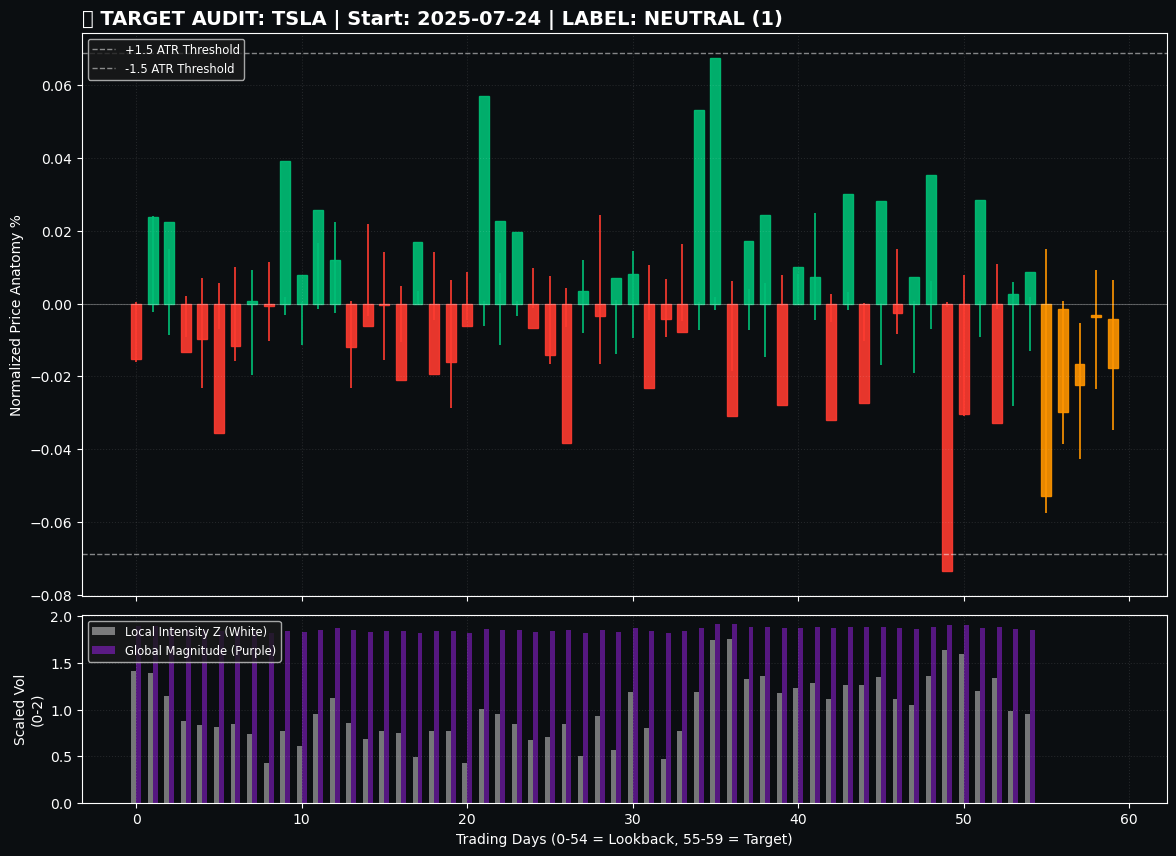

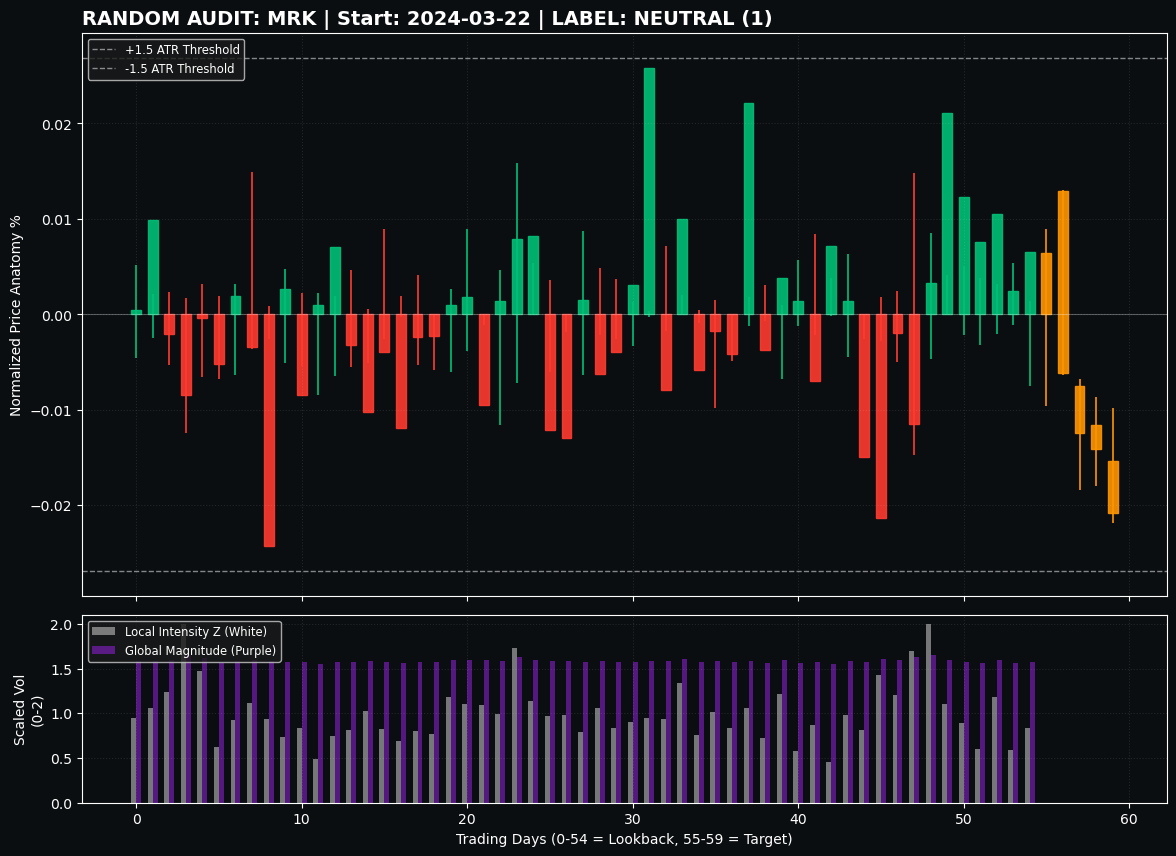

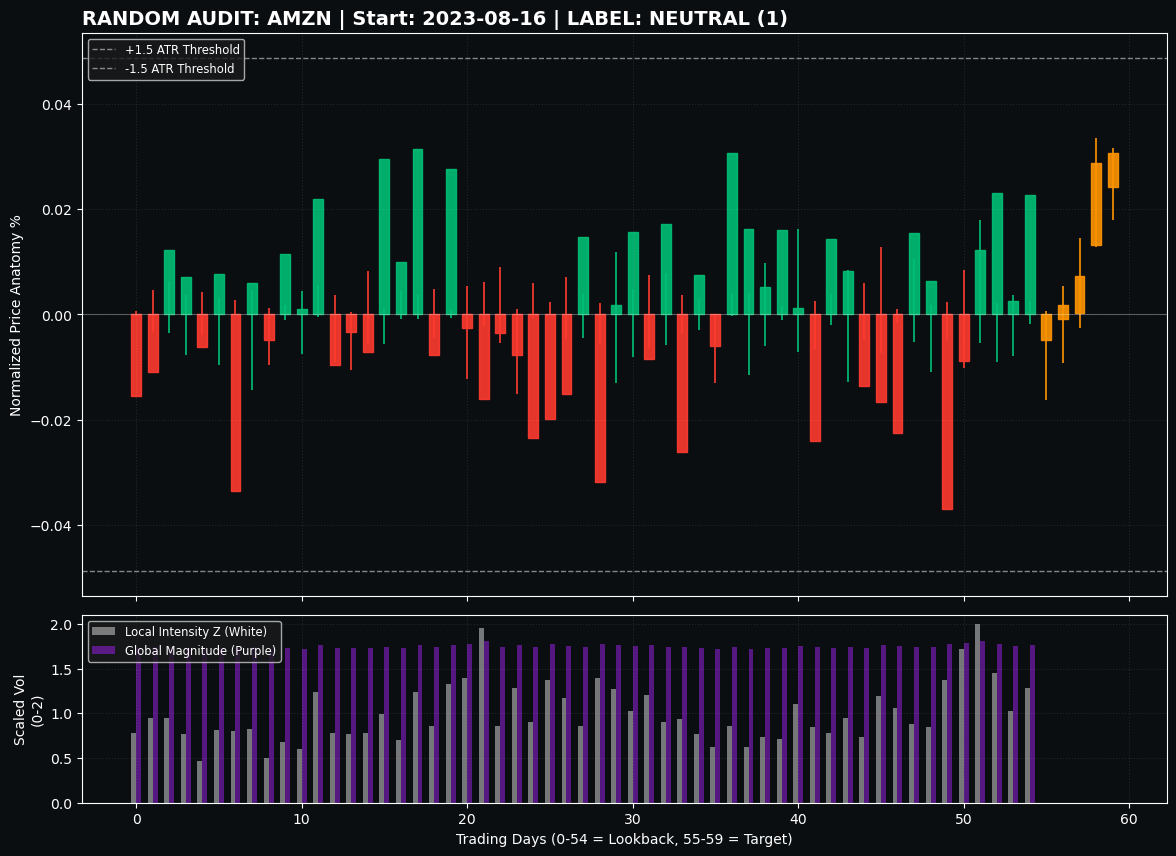

In [ ]:
# ===== Cell 5: Final Production Visualizer (SOTA Audit) =====
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from pathlib import Path

# --- Configuration ---
MASTER_OHLCV_PATH = Path("../data/master_dataset_OHLCV.pt")
ATR_MULTIPLIER = 1.5 # Ensure this matches your data generation

def plot_sota_audit(data_path):
    if not data_path.exists():
        print(f" Error: Master file not found at {data_path}")
        return
    samples = torch.load(data_path)

    # 1. Find TSLA Window (July 24, 2025)
    tsla_idx = next((i for i, s in enumerate(samples) if s['metadata']['ticker'] == "TSLA" and s['metadata']['window_start'] == "2025-07-24"), None)
    indices = [tsla_idx] if tsla_idx is not None else []
    # Fill with randoms
    while len(indices) < 3:
        idx = np.random.randint(0, len(samples))
        if idx not in indices: indices.append(idx)

    label_map = {0: "SELL (0)", 1: "NEUTRAL (1)", 2: "BUY (2)"}

    for i, idx in enumerate(indices):
        s = samples[idx]
        x, meta, p = s['x'], s['metadata'], s['plot_payload']

        # Setup separate figure structure (Main plot + Volume sub-plot)
        fig = plt.figure(figsize=(14, 10), facecolor='#0B0E11')
        gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax_main = fig.add_subplot(gs[0])
        ax_vol = fig.add_subplot(gs[1], sharex=ax_main)

        # ================= MAIN PRICE CHART (Percentage Scale) =================

        # --- 1. Lookback Candles (x columns 0-3: Gap, UW, LW, Body) ---
        for d in range(55):
            # In this view, 'Open' is always baseline 0
            gap, uw, lw, body = x[d, 0], x[d, 1], x[d, 2], x[d, 3]
            color = '#00C076' if body >= 0 else '#FF3B30'

            # Wick: High to Low relative to Open (0)
            ax_main.vlines(d, lw, uw, color=color, linewidth=1.2)
            # Body: Open (0) to Close (body value)
            bot, h = (0, body) if body >= 0 else (body, abs(body))
            ax_main.add_patch(patches.Rectangle((d-0.3, bot), 0.6, max(h, 0.0001), color=color, alpha=0.9))

        # --- 2. Target Candles (Orange, Relative to Anchor Open) ---
        anchor_price = p['anchor_open']
        target_raw = p['target_ohlc_raw'] # [5, 4] O,H,L,C

        for t_day in range(5):
            # Convert raw target OHLC to percentage relative to anchor Open
            to_pct = (target_raw[t_day, 0] / anchor_price) - 1
            th_pct = (target_raw[t_day, 1] / anchor_price) - 1
            tl_pct = (target_raw[t_day, 2] / anchor_price) - 1
            tc_pct = (target_raw[t_day, 3] / anchor_price) - 1

            plot_day = 55 + t_day
            color = '#FF9500' # Fixed Orange for targets

            # Wick
            ax_main.vlines(plot_day, tl_pct, th_pct, color=color, linewidth=1.2)
            # Body
            bot, h = (to_pct, tc_pct - to_pct) if tc_pct >= to_pct else (tc_pct, to_pct - tc_pct)
            ax_main.add_patch(patches.Rectangle((plot_day-0.3, bot), 0.6, max(h, 0.0001), color=color, alpha=0.9))

        # --- 3. ATR Thresholds (Converted to Percentage) ---
        # The threshold is +/- (1.5 * ATR_abs) relative to anchor price.
        # As a percentage of anchor price, this is simply +/- (1.5 * ATR_abs / anchor_price)
        atr_pct_threshold = (ATR_MULTIPLIER * p['anchor_atr']) / anchor_price

        ax_main.axhline(atr_pct_threshold, color='white', linestyle='--', linewidth=1, alpha=0.5, label=f'+{ATR_MULTIPLIER} ATR Threshold')
        ax_main.axhline(-atr_pct_threshold, color='white', linestyle='--', linewidth=1, alpha=0.5, label=f'-{ATR_MULTIPLIER} ATR Threshold')
        ax_main.axhline(0, color='white', linewidth=0.8, alpha=0.3) # Zero baseline

        # ================= VOLUME SUB-CHART (Scaled [0, 2]) =================
        # x columns 4 & 5 are [-1, 1]. Shift by +1 to make them [0, 2] for plotting.
        local_vol = x[:, 4] + 1
        global_vol = x[:, 5] + 1

        ax_vol.bar(np.arange(55)-0.15, local_vol, color='#E0E0E0', alpha=0.5, width=0.3, label='Local Intensity Z (White)')
        ax_vol.bar(np.arange(55)+0.15, global_vol, color='#A020F0', alpha=0.5, width=0.3, label='Global Magnitude (Purple)')

        # ================= AESTHETICS =================
        for ax in [ax_main, ax_vol]:
            ax.set_facecolor('#0B0E11')
            ax.grid(color='white', linestyle=':', alpha=0.1)
            ax.tick_params(colors='white')
            for spine in ax.spines.values(): spine.set_color('white')

        title_type = " TARGET AUDIT" if i == 0 else "RANDOM AUDIT"
        title_color = '#00C076' if s['y']==2 else '#FF3B30' if s['y']==0 else 'white'
        ax_main.set_title(f"{title_type}: {meta['ticker']} | Start: {meta['window_start']} | LABEL: {label_map[s['y']]}",
                          color=title_color, fontsize=14, fontweight='bold', loc='left')

        ax_main.set_ylabel("Normalized Price Anatomy %", color='white')
        ax_vol.set_ylabel("Scaled Vol\n(0-2)", color='white')
        ax_vol.set_xlabel("Trading Days (0-54 = Lookback, 55-59 = Target)", color='white')

        ax_main.legend(loc='upper left', fontsize='small', facecolor='#1A1A1A', labelcolor='white')
        ax_vol.legend(loc='upper left', fontsize='small', facecolor='#1A1A1A', labelcolor='white')

        # Hide X-ticks on main chart to avoid clutter
        plt.setp(ax_main.get_xticklabels(), visible=False)

        plt.show()

# Run Final Audit
plot_sota_audit(MASTER_OHLCV_PATH)

In [ ]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# --- 1. CONFIGURATION (Ensure these match your setup) ---
M_VALUES = [24, 40, 55]
TARGET_DAYS_LIST = [5, 10]
BASE_DATA = Path("../data")
INPUT_DIR = BASE_DATA / "raw_data"
MASTER_DIR = BASE_DATA / "full_dataset"

def get_inflation_factor(year):
    factors = {2020: 1.25, 2021: 1.20, 2022: 1.12, 2023: 1.07, 2024: 1.03, 2025: 1.00}
    return factors.get(year, 1.0)

# --- 2. EXECUTION ---
print(" Starting Retroactive Metadata Injection...")

for target_days in TARGET_DAYS_LIST:
    target_dir = MASTER_DIR / f"target_days_{target_days}"
    if not target_dir.exists(): continue

    for M in M_VALUES:
        file_path = target_dir / f"OHLCV_dates_ERdates_{M}.pt"
        if not file_path.exists(): continue

        print(f"\n Processing: {file_path.name} (Target: {target_days})")

        # Load the dataset
        samples = torch.load(file_path, weights_only=False)

        # Group samples by ticker to avoid reloading CSVs 10,000 times
        from collections import defaultdict
        ticker_groups = defaultdict(list)
        for i, s in enumerate(samples):
            ticker_groups[s['metadata']['ticker']].append(i)

        for ticker, indices in tqdm(ticker_groups.items(), desc=f"M={M}, T={target_days}", leave=False):
            # Load and Pre-process Raw Data
            raw_path = INPUT_DIR / f"{ticker}_RAW.csv"
            if not raw_path.exists(): continue

            df = pd.read_csv(raw_path)
            df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')

            # Re-calculate ATR exactly like Cell 4.5
            tr = pd.concat([
                (df['High'] - df['Low']),
                (df['High'] - df['Close'].shift()).abs(),
                (df['Low'] - df['Close'].shift()).abs()
            ], axis=1).max(axis=1)
            df['ATR_Abs'] = tr.rolling(window=14).mean()

            # Create a date-indexed lookup for speed
            df_lookup = df.set_index('Date')
            # Get integer positions for relative indexing
            df_pos = df.reset_index()

            for idx in indices:
                meta = samples[idx]['metadata']
                ref_date = meta['date'] # This is 't'

                try:
                    # Find integer position of 't'
                    pos_t = df_pos[df_pos['Date'] == ref_date].index[0]

                    # 1. Target OHLC (t+1 to t+target_days)
                    target_slice = df.iloc[pos_t + 1 : pos_t + 1 + target_days]
                    target_ohlc = target_slice[['Open', 'High', 'Low', 'Close']].values

                    # 2. Anchor Price (Open of t+1)
                    anchor_open = df.iloc[pos_t + 1]['Open']

                    # 3. Anchor ATR (ATR of t)
                    anchor_atr = df.iloc[pos_t]['ATR_Abs']

                    # Inject Payload
                    samples[idx]['plot_payload'] = {
                        'target_ohlc_raw': target_ohlc.astype(np.float32),
                        'anchor_open': float(anchor_open),
                        'anchor_atr': float(anchor_atr)
                    }
                except Exception as e:
                    # Likely end-of-file boundary
                    continue

        # Save updated file
        torch.save(samples, file_path)
        print(f" Successfully updated {file_path.name}")

print("\n All files updated! You can now run the Visualizer.")

🔍 Info: 'plot_payload' missing or incomplete for M=24. Target candles cannot be drawn.


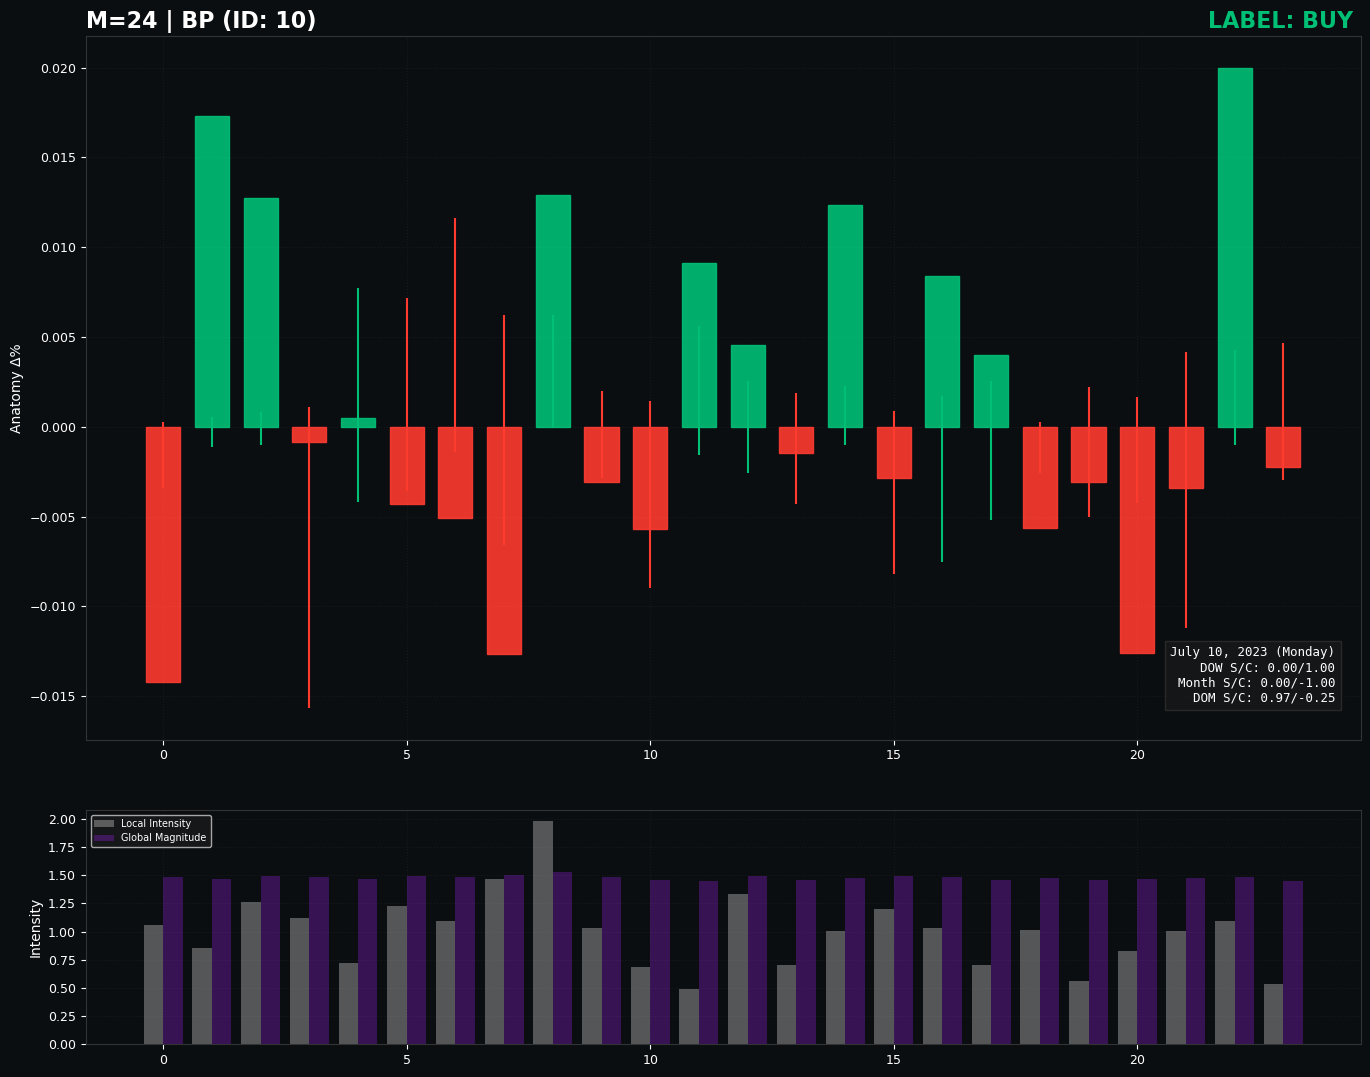

🔍 Info: 'plot_payload' missing or incomplete for M=40. Target candles cannot be drawn.


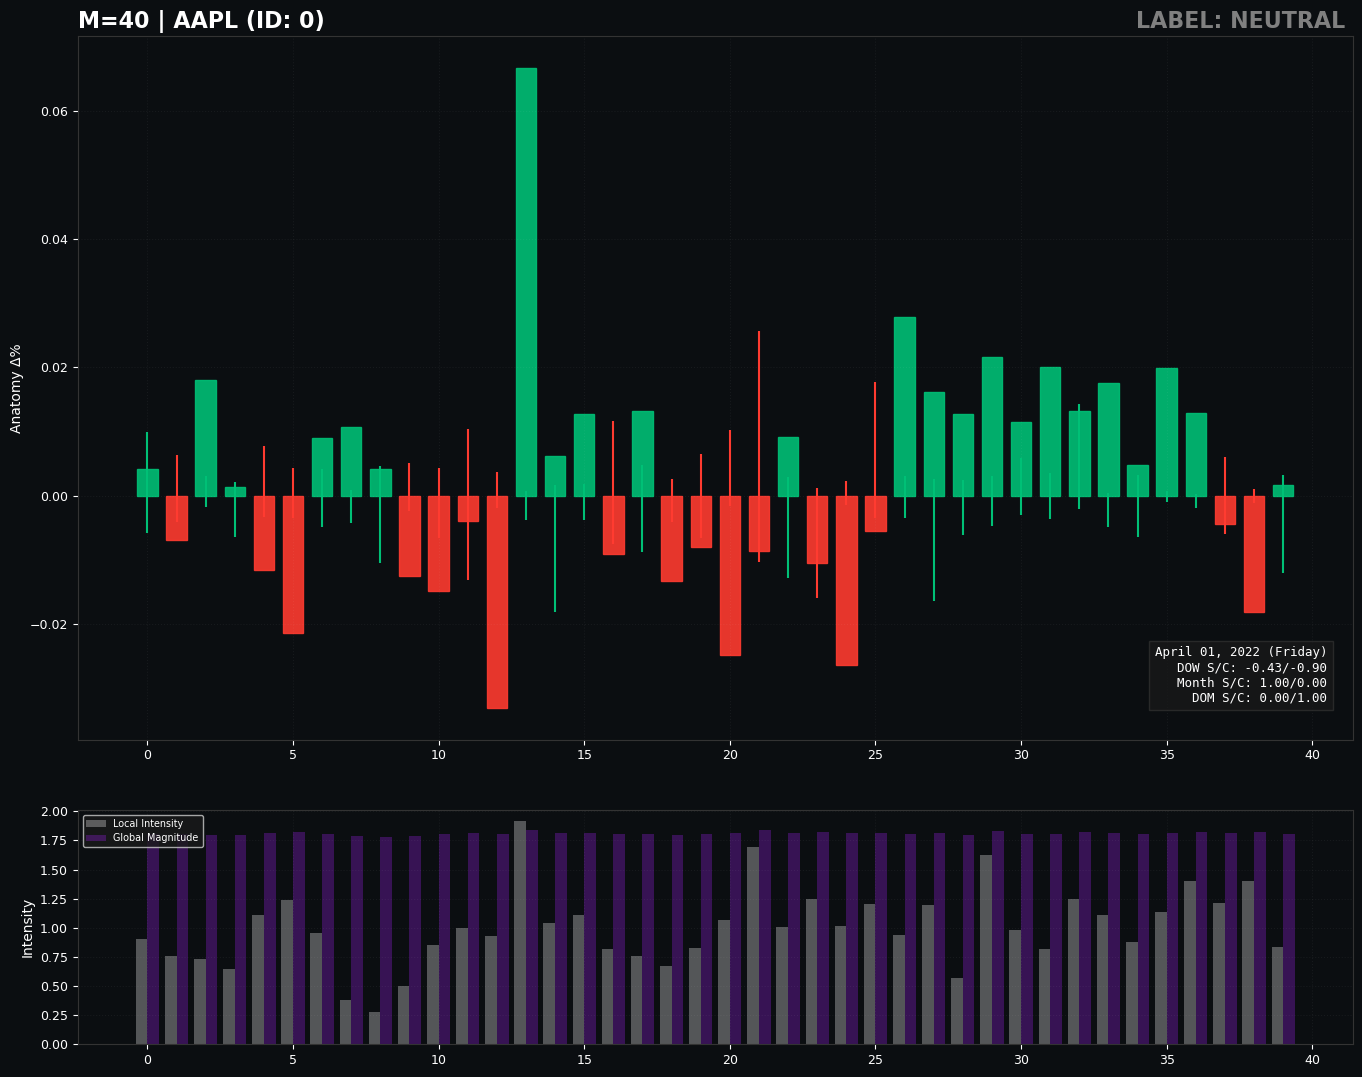

🔍 Info: 'plot_payload' missing or incomplete for M=55. Target candles cannot be drawn.


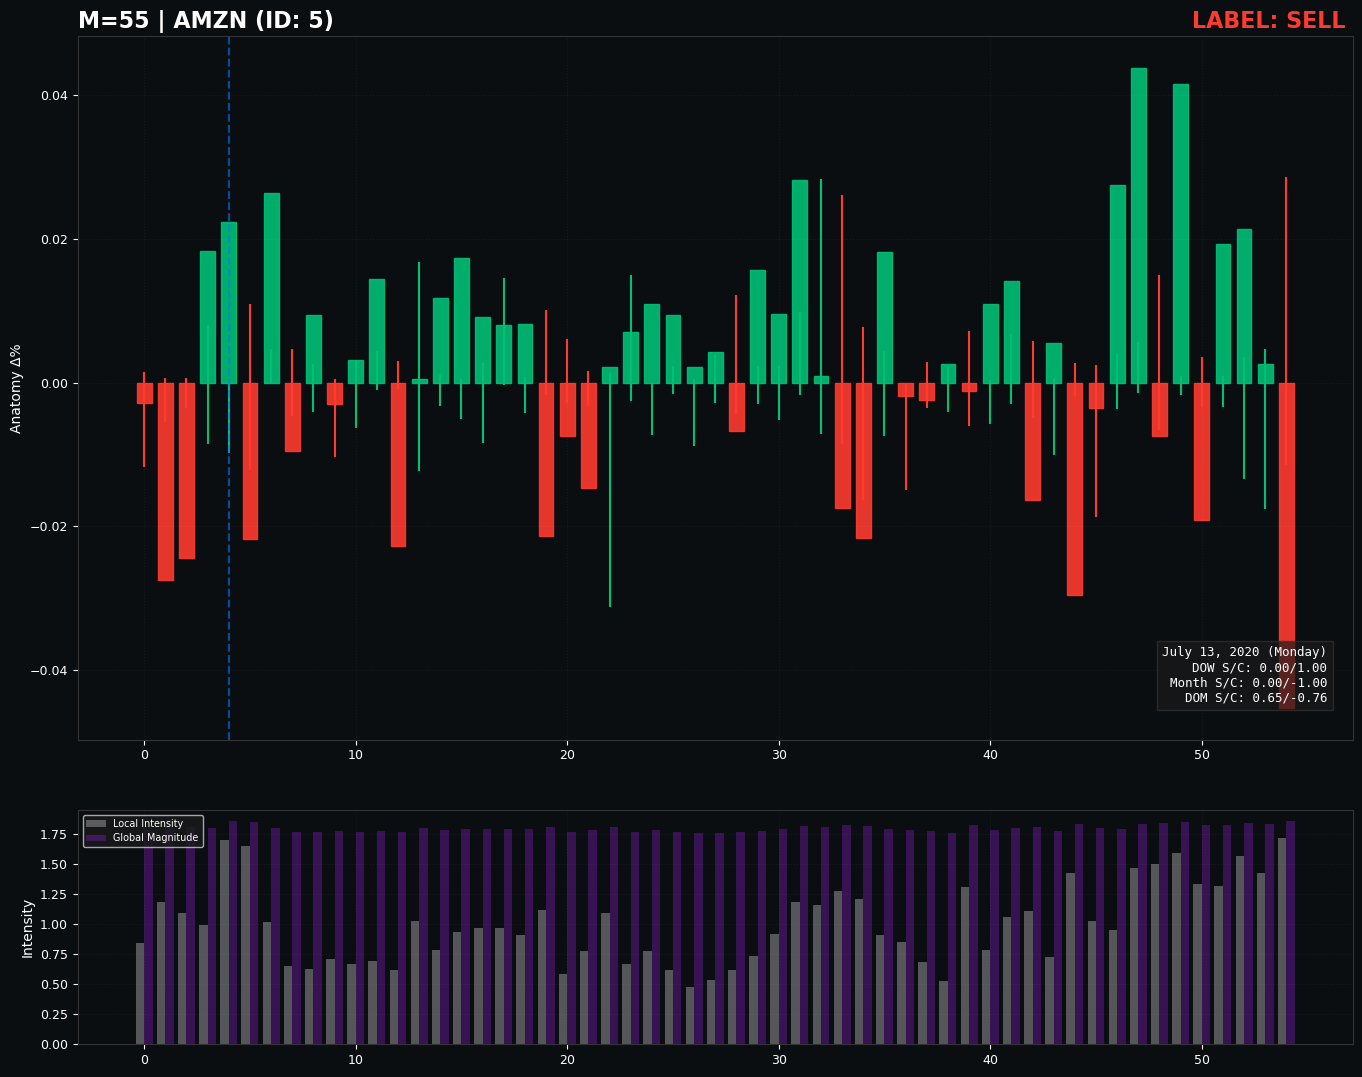

In [ ]:
# ===== Cell 5.5: Full data illustration =====

# ===== Cell 6: Master Dataset Audit (Fixed for Targets & ATR) =====
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
M_VALUES = [24, 40, 55]
TARGET_DAYS = 5
BASE_DATA_DIR = Path(f"../data/full_dataset/target_days_{TARGET_DAYS}")
ATR_MULTIPLIER = 1.5

def plot_multi_m_audit():
    for M in M_VALUES:
        file_path = BASE_DATA_DIR / f"OHLCV_dates_ERdates_{M}.pt"
        if not file_path.exists():
            print(f" File not found: {file_path}")
            continue

        # Load data with weights_only=False to allow dictionary loading
        samples = torch.load(file_path, weights_only=False)
        s = samples[np.random.randint(0, len(samples))]

        # Extraction
        x = s['x']
        meta = s['metadata']
        static_id = s.get('static_id', "N/A")
        y = s['y']
        p = s.get('plot_payload', None)
        curr_date = pd.to_datetime(meta['date'])

        # Setup Figure
        fig = plt.figure(figsize=(15, 12), facecolor='#0B0E11')
        gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.15)
        ax_main = fig.add_subplot(gs[0])
        ax_vol = fig.add_subplot(gs[1], sharex=ax_main)

        # 1. Price Candles (Lookback)
        for d in range(M):
            gap, uw, lw, body = x[d, 0], x[d, 1], x[d, 2], x[d, 3]
            color = '#00C076' if body >= 0 else '#FF3B30'
            ax_main.vlines(d, lw, uw, color=color, linewidth=1.5)
            bot, h = (0, body) if body >= 0 else (body, abs(body))
            ax_main.add_patch(patches.Rectangle((d-0.35, bot), 0.7, max(h, 0.0005), color=color, alpha=0.9))

            # Feature index 12 is the ER Flag
            if x[d, 12] > 0.5:
                ax_main.axvline(d, color='#007AFF', linestyle='--', linewidth=1.5, alpha=0.6)

        # 2. Target Orange Candles & ATR Barriers
        if p is not None and 'target_ohlc_raw' in p and 'anchor_atr' in p:
            anchor = p.get('anchor_open', 1.0)

            # --- Draw ATR Thresholds ---
            atr_pct = (ATR_MULTIPLIER * p['anchor_atr']) / anchor
            ax_main.axhline(atr_pct, color='#FFFFFF', linestyle='--', alpha=0.5, label=f'+{ATR_MULTIPLIER} ATR')
            ax_main.axhline(-atr_pct, color='#FFFFFF', linestyle='--', alpha=0.5, label=f'-{ATR_MULTIPLIER} ATR')
            ax_main.axhline(0, color='white', linewidth=0.5, alpha=0.2) # Baseline

            # --- Draw Target Candles ---
            for t_day in range(len(p['target_ohlc_raw'])):
                target = p['target_ohlc_raw'][t_day]
                # Reconstruct relative to anchor open: (Raw / Anchor) - 1
                to, th, tl, tc = (target / anchor) - 1
                plot_day = M + t_day
                color = '#FF9500' # Target Orange
                ax_main.vlines(plot_day, tl, th, color=color, linewidth=1.8)
                bot, h = (to, tc-to) if tc >= to else (tc, to-tc)
                ax_main.add_patch(patches.Rectangle((plot_day-0.35, bot), 0.7, max(h, 0.0005), color=color))
        else:
            print(f" Info: 'plot_payload' missing or incomplete for M={M}. Target candles cannot be drawn.")

        # 3. Volume Intensity
        ax_vol.bar(np.arange(M)-0.2, x[:, 4]+1, color='white', alpha=0.3, width=0.4, label='Local Intensity')
        ax_vol.bar(np.arange(M)+0.2, x[:, 5]+1, color='#A020F0', alpha=0.3, width=0.4, label='Global Magnitude')

        # ================= AESTHETICS =================
        ax_main.set_title(f"M={M} | {meta['ticker']} (ID: {static_id})", color='white', fontsize=16, fontweight='bold', loc='left')

        label_map = {0: "SELL", 1: "NEUTRAL", 2: "BUY"}
        l_color = '#00C076' if y==2 else '#FF3B30' if y==0 else 'gray'
        ax_main.set_title(f"LABEL: {label_map[y]} ", color=l_color, fontsize=16, fontweight='bold', loc='right')

        # Calendar Box
        cal_vals = x[-1, 6:12]
        cal_str = (f"{curr_date.strftime('%B %d, %Y')} ({curr_date.day_name()})\n"
                   f"DOW S/C: {cal_vals[0]:.2f}/{cal_vals[1]:.2f}\n"
                   f"Month S/C: {cal_vals[2]:.2f}/{cal_vals[3]:.2f}\n"
                   f"DOM S/C: {cal_vals[4]:.2f}/{cal_vals[5]:.2f}")

        ax_main.text(0.98, 0.05, cal_str, transform=ax_main.transAxes, color='white',
                     fontsize=9, ha='right', va='bottom', family='monospace',
                     bbox=dict(facecolor='#1A1A1A', alpha=0.7, edgecolor='#333333'))

        for ax in [ax_main, ax_vol]:
            ax.set_facecolor('#0B0E11')
            ax.tick_params(colors='white', labelsize=9)
            ax.grid(True, color='white', alpha=0.05, linestyle=':')
            for spine in ax.spines.values(): spine.set_color('#333333')

        ax_main.set_ylabel("Anatomy Δ%", color='white')
        ax_vol.set_ylabel("Intensity", color='white')
        ax_vol.legend(loc='upper left', fontsize='x-small', facecolor='#1A1A1A', labelcolor='white')

        # Use constrained_layout or manual padding instead of tight_layout to avoid warnings
        plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.2)
        plt.show()

plot_multi_m_audit()

# ===== End of cell 5.5 =====

In [ ]:
# ===== Cell 6: Class Distribution & Dataset Balance Audit =====
import torch
import pandas as pd
from collections import Counter
from pathlib import Path

# --- Configuration ---
MASTER_OHLCV_PATH = Path("../data/master_dataset_OHLCV.pt")

def print_class_distribution(data_path):
    if not data_path.exists():
        print(f" Error: Master file not found at {data_path}")
        return

    # 1. Load the self-contained Master File
    samples = torch.load(data_path)
    total_samples = len(samples)

    # 2. Extract Labels (y)
    # The 'y' key contains the classification (0, 1, or 2)
    labels = [s['y'] for s in samples]
    counts = Counter(labels)

    # 3. Format the Results
    label_names = {0: "SELL (0)", 1: "NEUTRAL (1)", 2: "BUY (2)"}

    print("-" * 40)
    print(f" DATASET BALANCE AUDIT: {data_path.name}")
    print(f"Total Windows: {total_samples:,}")
    print("-" * 40)

    # Sort by label (0, 1, 2)
    for label in sorted(counts.keys()):
        count = counts[label]
        pct = (count / total_samples) * 100
        name = label_names.get(label, f"Unknown ({label})")
        print(f"{name:<12}: {count:>8,} samples | {pct:>6.2f}%")

    print("-" * 40)

    # 4. Optional: Distribution by Ticker (Top 5)
    tickers = [s['metadata']['ticker'] for s in samples]
    ticker_counts = Counter(tickers)
    print(f"Sample Count Per Ticker (Avg): {total_samples / len(ticker_counts):.0f}")

# Execute Audit
print_class_distribution(MASTER_OHLCV_PATH)

In [ ]:
import torch
import numpy as np
from pathlib import Path
import os

model_path = Path("..") / "results" / "best_runs" / "tft" / "final_models" / "Wide_Shallow_Standard_Final_best.pth"

# --- 1. DYNAMIC PATHING ---
# PyCharm project structure: assumes data is in the same folder or 'data' subfolder
BASE_DIR = Path("..")
SOURCE_PATH = BASE_DIR / "data" / "master_dataset_OHLCV.pt"
TARGET_PATH = BASE_DIR / "master_dataset_REGRESSION.pt"

def transform_to_regression():
    if not SOURCE_PATH.exists():
        print(f" Error: Could not find {SOURCE_PATH}")
        return

    print(f" Loading SOURCE: {SOURCE_PATH.name}...")
    # weights_only=False is required for the dictionary structure
    data = torch.load(SOURCE_PATH, weights_only=False)

    new_data = []
    print(f"  Calculating exact returns for {len(data)} windows...")

    for entry in data:
        # Extract existing components
        x_tensor = entry['x']
        meta = entry.get('metadata', {})
        payload = entry.get('plot_payload', {})

        # --- FLEXIBLE RETURN CALCULATION ---
        # Logic: C[last target day] / O[first target day] - 1
        try:
            target_ohlc = payload['target_ohlc_raw'] # Shape: [Target_Len, 4]

            # Open of the first target day (Index 0, Column 0)
            open_first = target_ohlc[0, 0]
            # Close of the last target day (Index -1, Column 3)
            close_last = target_ohlc[-1, 3]

            # Calculate precision percentage return
            actual_return = (close_last / open_first) - 1.0

        except (KeyError, IndexError, TypeError):
            # Fallback logic if payload is missing: Use the old proxy mapping
            # to prevent script failure, but flag it
            actual_return = float(entry['y'] - 1) * 0.015
            print(f" Warning: Missing payload for {meta.get('ticker', 'Unknown')}. Using proxy.")

        # Create the new standardized entry
        new_entry = {
            'x': x_tensor,
            'y': actual_return,  # The critical % return
            'metadata': {
                'ticker': meta.get('ticker', 'N/A'),
                'window_start': meta.get('window_start', 'N/A'),
                'window_idx': meta.get('window_idx', -1),
                'target_days': len(payload.get('target_ohlc_raw', [])) # Flexible tracking
            },
            'plot_payload': payload # Keep for Cell 5 visualization
        }
        new_data.append(new_entry)

    # Save sibling file (does not override original)
    print(f" Saving TARGET: {TARGET_PATH.name}...")
    torch.save(new_data, TARGET_PATH)

    # Audit Stats
    y_stats = [d['y'] for d in new_data]
    print("\n" + "="*45)
    print(" DATASET AUDIT (REGRESSION)")
    print("="*45)
    print(f" Samples:        {len(new_data)}")
    print(f" Max Return:     {max(y_stats):.2%}")
    print(f" Min Return:     {min(y_stats):.2%}")
    print(f"  Avg Return:    {np.mean(y_stats):.4%}")
    print(f" Features:       {x_tensor.shape[1]} (OHLCV+)")
    print("="*45)

if __name__ == "__main__":
    transform_to_regression()

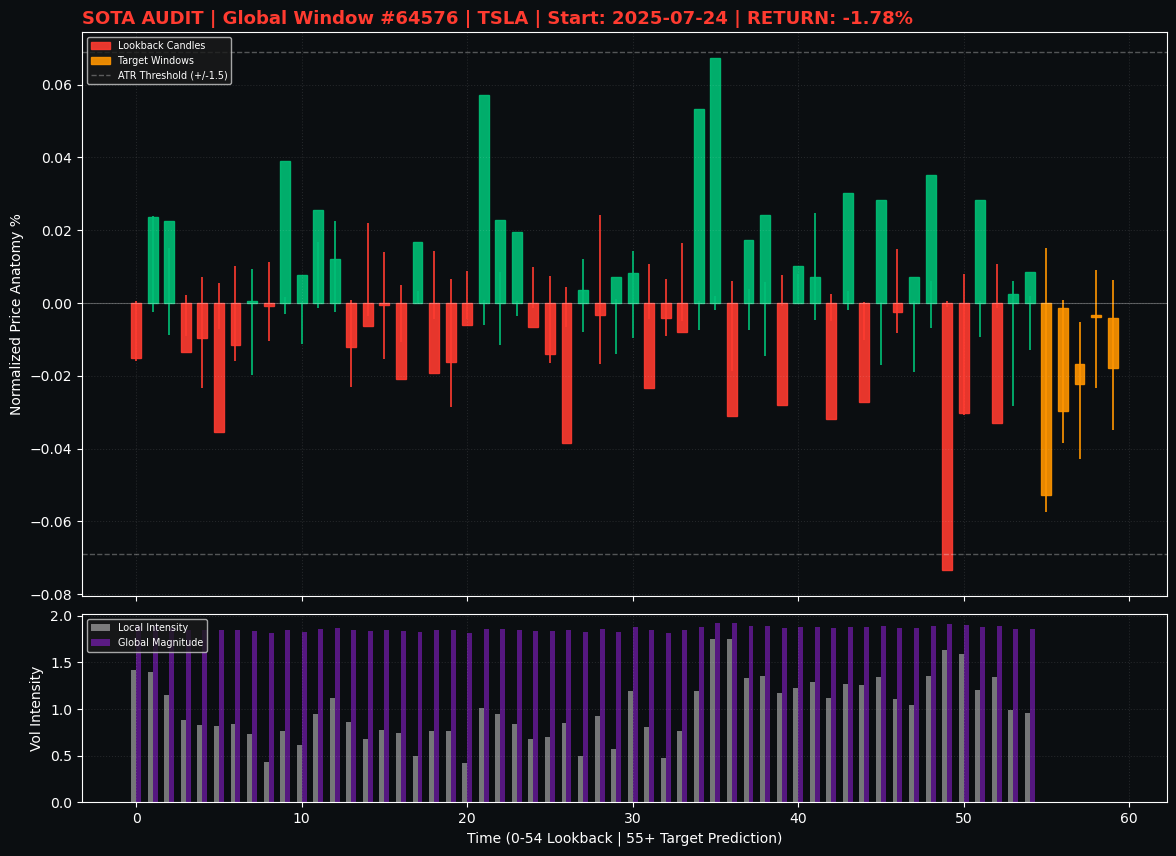

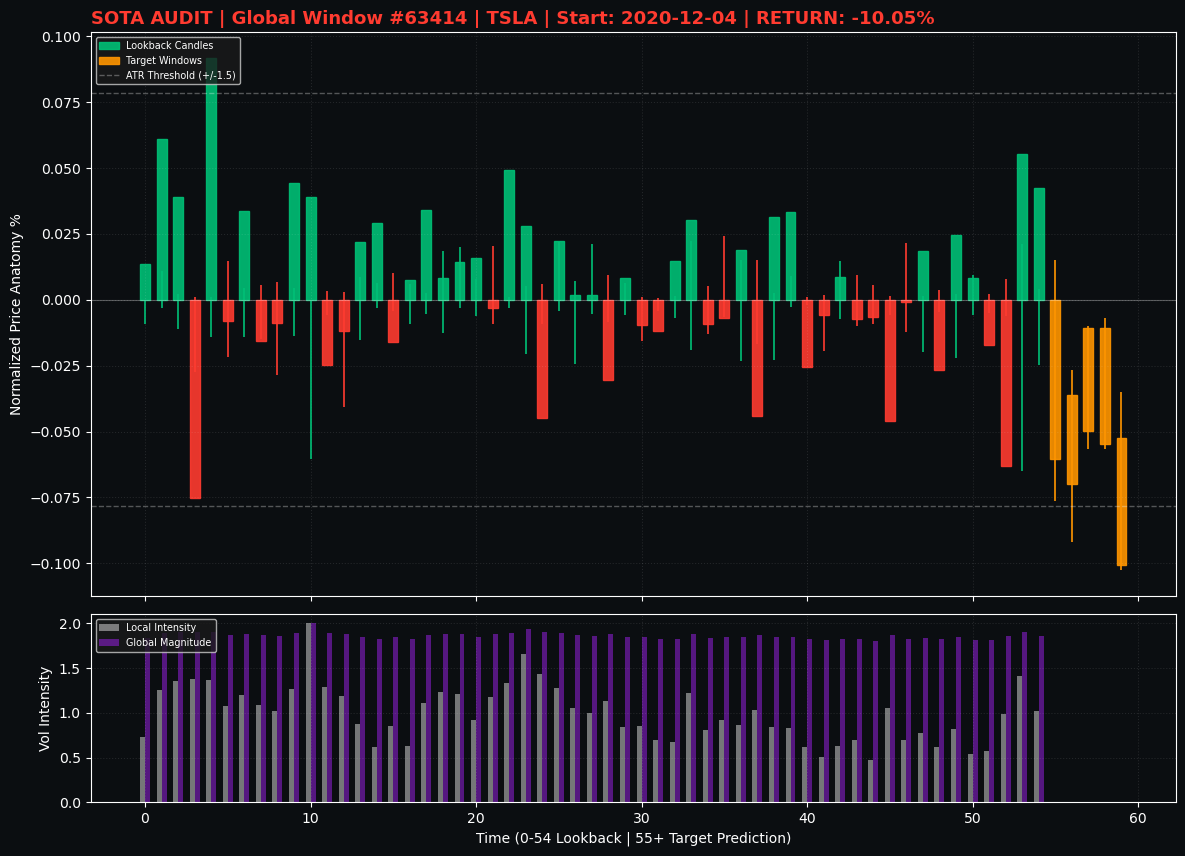

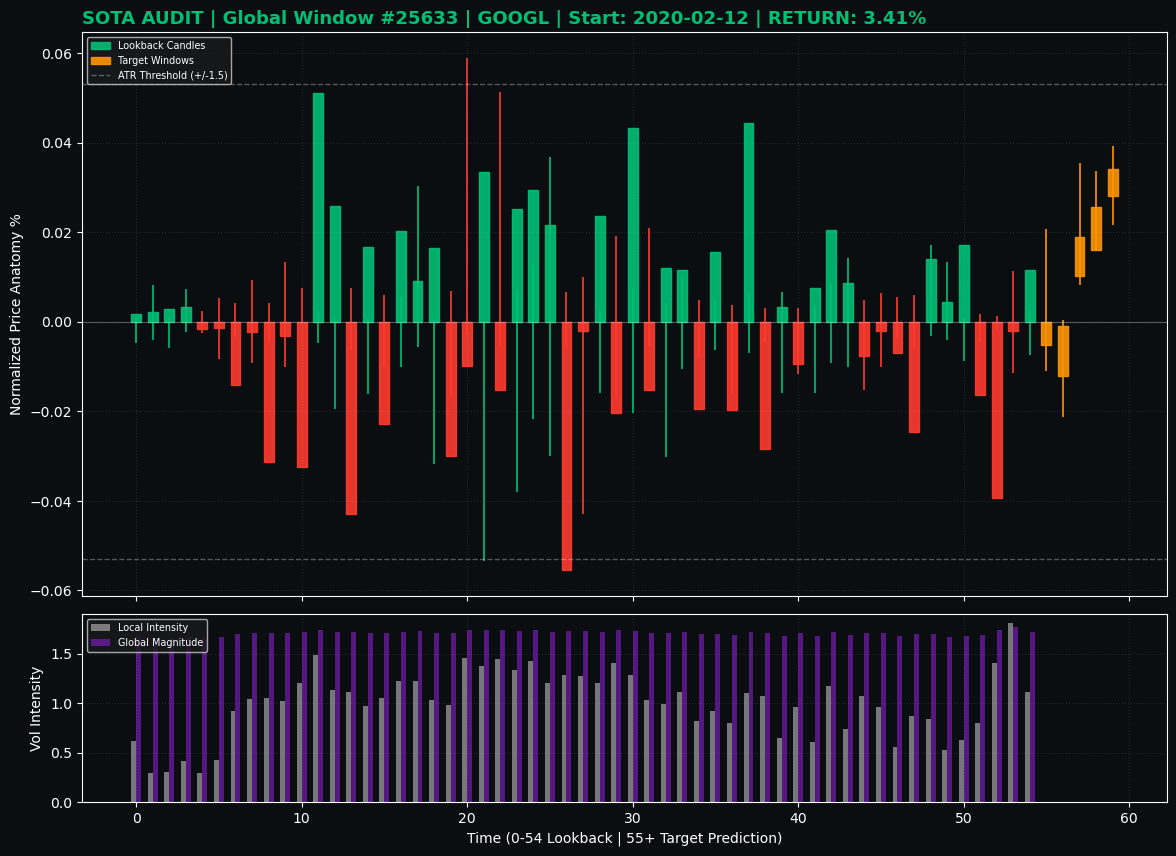

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from pathlib import Path

# --- Configuration ---
# Updated to point to your new regression sibling file
MASTER_REGRESSION_PATH = BASE_DIR / "master_dataset_REGRESSION.pt"
ATR_MULTIPLIER = 1.5

def plot_regression_sota_audit(data_path):
    if not data_path.exists():
        print(f" Error: Master file not found at {data_path}")
        return

    # weights_only=False is required for the dictionary structure
    samples = torch.load(data_path, weights_only=False)

    # 1. Selection Logic (TSLA Specific + Randoms)
    tsla_idx = next((i for i, s in enumerate(samples)
                     if s['metadata']['ticker'] == "TSLA" and
                     s['metadata']['window_start'] == "2025-07-24"), None)

    indices = [tsla_idx] if tsla_idx is not None else []
    while len(indices) < 3:
        idx = np.random.randint(0, len(samples))
        if idx not in indices: indices.append(idx)

    for i, idx in enumerate(indices):
        s = samples[idx]
        x, meta, p = s['x'], s['metadata'], s['plot_payload']
        y_return = s['y'] # Continuous return value

        fig = plt.figure(figsize=(14, 10), facecolor='#0B0E11')
        gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax_main = fig.add_subplot(gs[0])
        ax_vol = fig.add_subplot(gs[1], sharex=ax_main)

        # ================= MAIN PRICE CHART (Lookback) =================
        for d in range(55):
            gap, uw, lw, body = x[d, 0], x[d, 1], x[d, 2], x[d, 3]
            color = '#00C076' if body >= 0 else '#FF3B30'

            # Label only the first candle to avoid legend clutter
            label = "Lookback Candles" if d == 0 else ""
            ax_main.vlines(d, lw, uw, color=color, linewidth=1.2)
            bot, h = (0, body) if body >= 0 else (body, abs(body))
            ax_main.add_patch(patches.Rectangle((d-0.3, bot), 0.6, max(h, 0.0001),
                                                color=color, alpha=0.9, label=label))

        # ================= TARGET CANDLES (Orange) =================
        anchor_price = p['anchor_open']
        target_raw = p['target_ohlc_raw']

        for t_day in range(len(target_raw)):
            to_pct = (target_raw[t_day, 0] / anchor_price) - 1
            th_pct = (target_raw[t_day, 1] / anchor_price) - 1
            tl_pct = (target_raw[t_day, 2] / anchor_price) - 1
            tc_pct = (target_raw[t_day, 3] / anchor_price) - 1

            plot_day = 55 + t_day
            color = '#FF9500'
            label = "Target Windows" if t_day == 0 else ""
            ax_main.vlines(plot_day, tl_pct, th_pct, color=color, linewidth=1.2)
            bot, h = (to_pct, tc_pct - to_pct) if tc_pct >= to_pct else (tc_pct, to_pct - tc_pct)
            ax_main.add_patch(patches.Rectangle((plot_day-0.3, bot), 0.6, max(h, 0.0001),
                                                color=color, alpha=0.9, label=label))

        # ATR Thresholds
        atr_pct = (ATR_MULTIPLIER * p['anchor_atr']) / anchor_price
        ax_main.axhline(atr_pct, color='white', linestyle='--', linewidth=1, alpha=0.3, label=f'ATR Threshold (+/-{ATR_MULTIPLIER})')
        ax_main.axhline(-atr_pct, color='white', linestyle='--', linewidth=1, alpha=0.3)
        ax_main.axhline(0, color='white', linewidth=0.8, alpha=0.3)

        # ================= VOLUME SUB-CHART =================
        local_vol = x[:, 4] + 1
        global_vol = x[:, 5] + 1
        ax_vol.bar(np.arange(55)-0.15, local_vol, color='#E0E0E0', alpha=0.5, width=0.3, label='Local Intensity')
        ax_vol.bar(np.arange(55)+0.15, global_vol, color='#A020F0', alpha=0.5, width=0.3, label='Global Magnitude')

        # ================= AESTHETICS =================
        for ax in [ax_main, ax_vol]:
            ax.set_facecolor('#0B0E11')
            ax.grid(color='white', linestyle=':', alpha=0.1)
            ax.tick_params(colors='white')
            for spine in ax.spines.values(): spine.set_color('white')

        # Formatting Window Info
        # idx is the global position (e.g., #0 for the very first, #72142 for the last)
        title_color = '#00C076' if y_return > 0 else '#FF3B30'
        title_text = f"SOTA AUDIT | Global Window #{idx} | {meta['ticker']} | Start: {meta['window_start']} | RETURN: {y_return:.2%}"
        ax_main.set_title(title_text, color=title_color, fontsize=13, fontweight='bold', loc='left')

        ax_main.set_ylabel("Normalized Price Anatomy %", color='white')
        ax_vol.set_ylabel("Vol Intensity", color='white')
        ax_vol.set_xlabel("Time (0-54 Lookback | 55+ Target Prediction)", color='white')

        ax_main.legend(loc='upper left', fontsize='x-small', facecolor='#1A1A1A', labelcolor='white')
        ax_vol.legend(loc='upper left', fontsize='x-small', facecolor='#1A1A1A', labelcolor='white')

        plt.setp(ax_main.get_xticklabels(), visible=False)
        plt.show()

# Run Audit
plot_regression_sota_audit(MASTER_REGRESSION_PATH)